In [9]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()

Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=64, bias=True)
    (k_proj): Linear(in_features=768, out_features=64, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_la

In [2]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [3]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





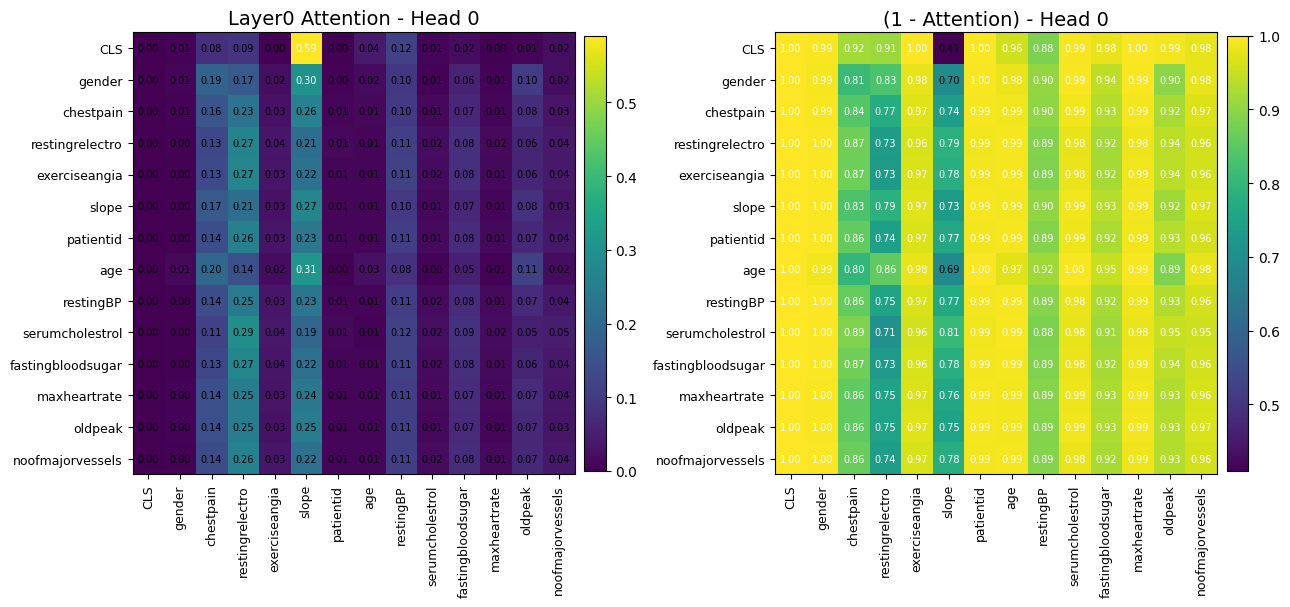

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0285 | std=0.2829
         gender  | mean=0.0140 | std=2.3778
      chestpain  | mean=0.2346 | std=5.5411
restingrelectro  | mean=0.2869 | std=6.4791
  exerciseangia  | mean=0.0254 | std=2.4438
          slope  | mean=0.2223 | std=5.6060
      patientid  | mean=0.2368 | std=6.9917
            age  | mean=-0.0833 | std=2.8170
      restingBP  | mean=0.2392 | std=6.2144
serumcholestrol  | mean=-0.1003 | std=1.4847
fastingbloodsugar  | mean=-0.2075 | std=3.8094
   maxheartrate  | mean=0.1686 | std=4.1450
        oldpeak  | mean=0.1404 | std=4.0140
noofmajorvessels  | mean=0.2141 | std=4.9220

=== Global embedding statistics ===
global mean: 0.0973
global std : 4.5183


In [5]:
src = sources[1]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)




========== Simulating LCG Initialization Strategies ==========
>> 1. Collecting CLS tokens from Vanilla GAT...
   >> Total CLS Collected: 3270
>> Simulating Strategy: [SEQUENTIAL]...
>> Simulating Strategy: [ROUND_ROBIN]...
>> Simulating Strategy: [HIERARCHICAL]...
>> Simulating Strategy: [DENSITY]...


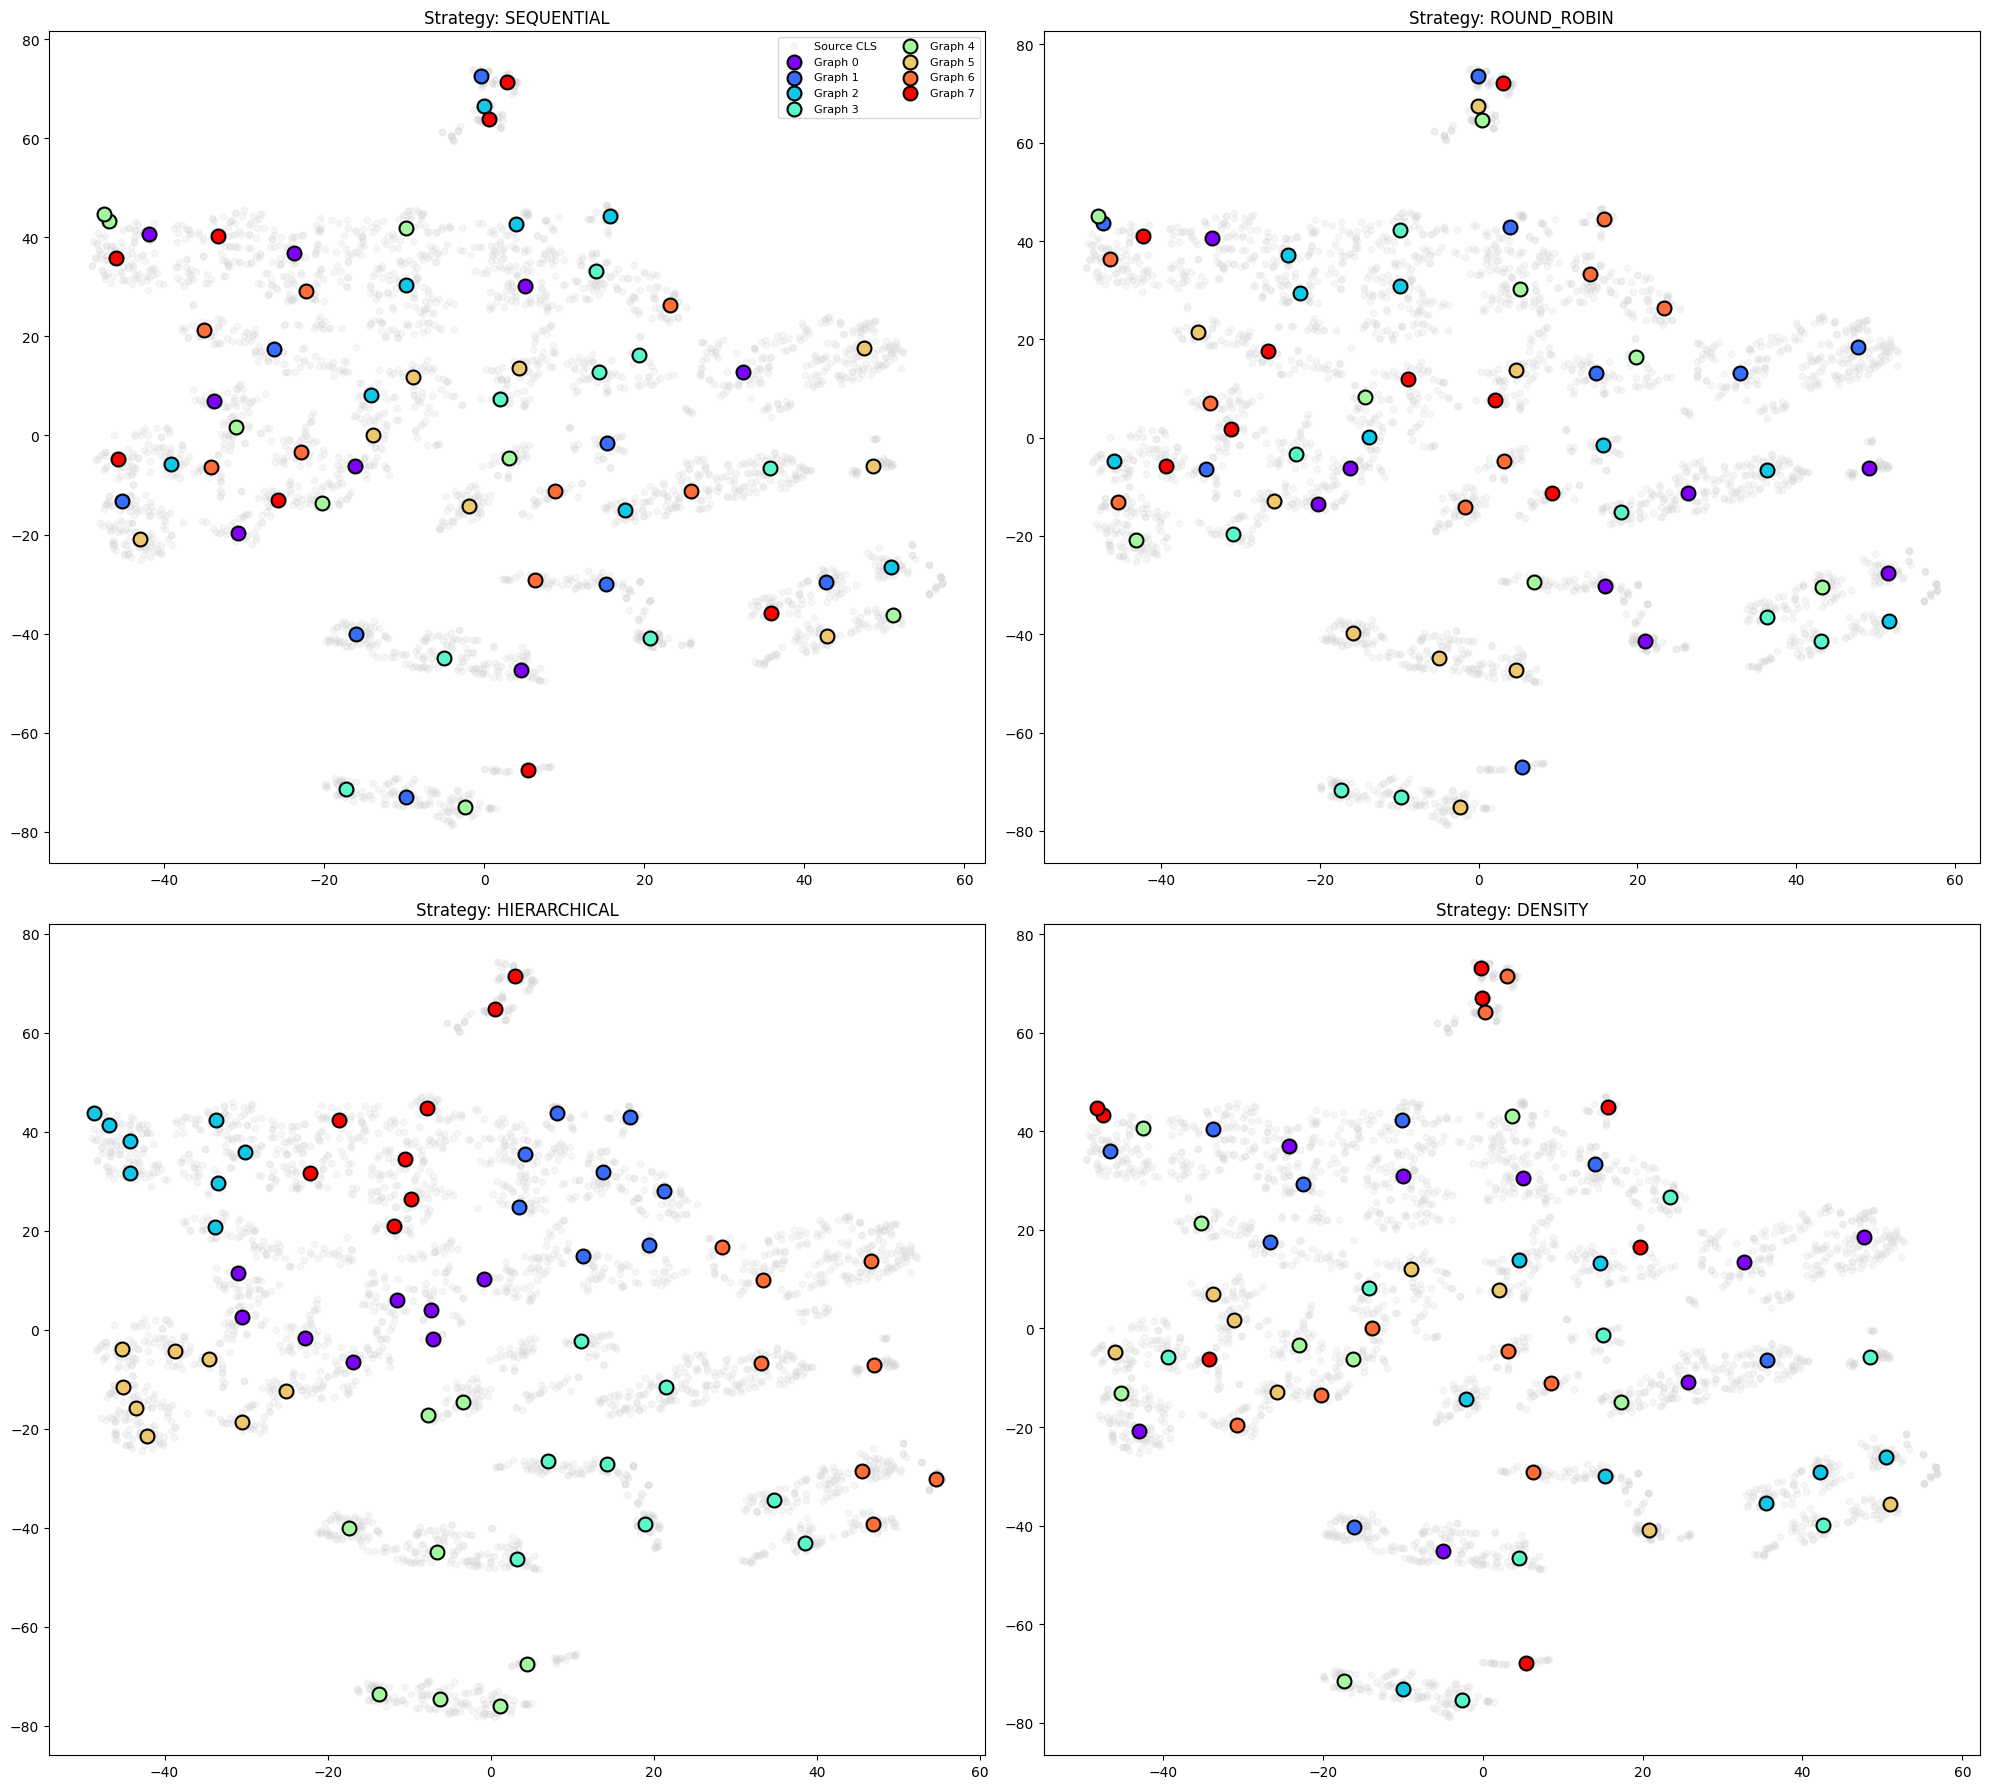

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

def simulate_and_visualize_strategies(model, loaders, device, M=8, K=8, num_vis_samples=3000):
    print(f"\n{'='*10} Simulating LCG Initialization Strategies {'='*10}")
    
    # --- Step 1. Collect Pre-trained CLS Tokens ---
    print(">> 1. Collecting CLS tokens from Vanilla GAT...")
    all_cls = []
    model.eval()
    
    with torch.no_grad():
        for src_name, loader in loaders.items():
            for batch in loader:
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # GAT Forward Logic (CLS Extraction)
                name_embs, val_embs = [], []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs: continue
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                # CLS Token (Index 0)
                cls_token = x_basis[:, 0, :].cpu().numpy()
                all_cls.append(cls_token)
                
                # 너무 많으면 메모리 터지니 2만개 정도만 수집
                if sum([len(x) for x in all_cls]) > 20000: break
    
    pool_cls = np.concatenate(all_cls, axis=0)
    print(f"   >> Total CLS Collected: {pool_cls.shape[0]}")

    # --- Step 2. Define Strategies ---
    strategies = ['sequential', 'round_robin', 'hierarchical', 'density']
    
    # 시각화용 Figure 생성 (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    # t-SNE를 위한 배경 데이터 샘플링 (속도 최적화)
    if pool_cls.shape[0] > num_vis_samples:
        idx = np.random.choice(pool_cls.shape[0], num_vis_samples, replace=False)
        vis_cls = pool_cls[idx]
    else:
        vis_cls = pool_cls

    for i, strategy in enumerate(strategies):
        print(f">> Simulating Strategy: [{strategy.upper()}]...")
        
        # --- Logic per Strategy ---
        centroids = None # Shape: [M, K, D]
        
        if strategy in ['sequential', 'round_robin', 'density']:
            # Global KMeans
            kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(pool_cls)
            centers = kmeans.cluster_centers_
            
            if strategy == 'sequential':
                # [M*K, D] -> [M, K, D]
                centroids = centers.reshape(M, K, -1)
                
            elif strategy == 'round_robin':
                # [M*K, D] -> [K, M, D] -> Transpose -> [M, K, D]
                centroids = centers.reshape(K, M, -1).transpose(1, 0, 2)
                
            elif strategy == 'density':
                # Sort by cluster size
                labels = kmeans.labels_
                counts = np.bincount(labels, minlength=M*K)
                sorted_idx = np.argsort(counts)[::-1] # Descending
                centroids = centers[sorted_idx].reshape(M, K, -1)
                
        elif strategy == 'hierarchical':
            # 2-Step KMeans
            centroids = np.zeros((M, K, pool_cls.shape[1]))
            km_global = KMeans(n_clusters=M, n_init=10, random_state=42).fit(pool_cls)
            
            for m in range(M):
                group = pool_cls[km_global.labels_ == m]
                # 데이터 부족 시 보충
                if len(group) < K:
                    supp = pool_cls[np.random.choice(len(pool_cls), K - len(group))]
                    group = np.concatenate([group, supp], axis=0)
                    
                km_local = KMeans(n_clusters=K, n_init=10, random_state=42).fit(group)
                centroids[m] = km_local.cluster_centers_

        # --- Step 3. t-SNE & Plotting ---
        # [CLS + Centroids]를 합쳐서 t-SNE 수행
        flat_centroids = centroids.reshape(-1, centroids.shape[-1])
        all_data = np.concatenate([vis_cls, flat_centroids], axis=0)
        
        # t-SNE (Perplexity 낮춤 for sparse centroids)
        tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
        embedded = tsne.fit_transform(all_data)
        
        idx_split = vis_cls.shape[0]
        emb_cls = embedded[:idx_split]
        emb_cen = embedded[idx_split:]
        
        # Plot
        ax = axes[i]
        # 배경 (Source CLS)
        ax.scatter(emb_cls[:, 0], emb_cls[:, 1], c='lightgray', alpha=0.2, s=20, label='Source CLS')
        
        # Centroids (Color by Graph ID)
        colors = cm.rainbow(np.linspace(0, 1, M))
        for m in range(M):
            start = m * K
            end = (m + 1) * K
            subset = emb_cen[start:end]
            ax.scatter(subset[:, 0], subset[:, 1], color=colors[m], marker='o', s=100, 
                       edgecolor='black', linewidth=1.5, label=f'Graph {m}' if i==0 else "")
            
        ax.set_title(f"Strategy: {strategy.upper()}")
        if i == 0: ax.legend(loc='best', ncol=2, fontsize=8)

    plt.tight_layout()
    plt.show()

# 실행
simulate_and_visualize_strategies(model, loaders, device, M=8, K=8)

In [20]:
from sklearn.cluster import KMeans
import torch
import numpy as np
import logging

def init_lcg_from_pretrained_cls(args, model, loaders, device, strategy='round_robin', injection_scale=1.0):
    """
    [Bridge Step] Pre-trained GAT의 CLS 토큰을 모아 LCG를 초기화하는 함수
    """
    print(f"\n{'='*20} [Bridge] LCG INIT from Pre-trained CLS {'='*20}")
    
    all_cls_tokens = []
    model.eval()
    max_samples = 50000 
    total_collected = 0
    
    # 1. Data Collection (Forward Pass to get CLS)
    print(">> 1. Collecting CLS tokens from Pre-trained Model...")
    
    with torch.no_grad():
        # loaders가 dict인지 list인지 확인하여 순회
        iterator = loaders.items() if isinstance(loaders, dict) else enumerate(loaders)
        
        for src_name, loader in iterator:
            for i, batch in enumerate(loader):
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # --- Embeddings Gather ---
                name_embs, val_embs = [], []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs: continue
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                # --- BasisGAT Stack (CLS 추출용) ---
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                # CLS Extraction (Index 0)
                cls_token = x_basis[:, 0, :].cpu().numpy()
                all_cls_tokens.append(cls_token)
                
                total_collected += cls_token.shape[0]
                if total_collected >= max_samples: break
            if total_collected >= max_samples: break

    data_pool = np.concatenate(all_cls_tokens, axis=0)
    print(f">> Collected {data_pool.shape[0]} CLS samples.")

    # 2. K-Means
    M = model.latent_graph.M
    K = model.latent_graph.K
    D = model.latent_graph.D
    
    print(f">> 2. Running K-Means ({M*K} clusters)...")
    kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(data_pool)
    centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
    
    # 3. Strategy Assignment
    final_centroids = torch.zeros(M, K, D)
    if strategy == 'round_robin':
        final_centroids = centers.view(K, M, D).transpose(0, 1).contiguous()
    else: # sequential
        final_centroids = centers.view(M, K, D)

    # 4. Variance Injection
    src_std = np.std(data_pool, axis=0)
    noise = torch.randn_like(final_centroids) * torch.tensor(src_std) * injection_scale
    final_init = final_centroids + noise
    
    # 5. Update Parameter
    with torch.no_grad():
        model.latent_graph.node_embeddings.data.copy_(final_init.to(device))
        
    print(f">> ✅ LCG Parameters Updated. (Strategy: {strategy})")

In [21]:
from models.LCG import LatentCompositeGraph
import torch
import logging
import numpy as np

def compare_init_strategies(model, loaders, device, num_epochs=3):
    """
    Random Init vs CLS K-Means Init의 초기 학습 양상을 비교하는 함수.
    GAT는 고정하고, 두 개의 LCG만 학습시키며 Loss 추이를 관찰함.
    """
    print(f"\n{'='*20} COMPARING INIT STRATEGIES (RAND vs DESC) {'='*20}")
    
    # 1. 모델 준비 (두 개의 LCG 생성)
    # args는 model.args를 사용하거나 외부에서 주입
    D = model.input_dim
    M, K = 8, 8 # 사용자 지정 (args.n_graphs, args.n_nodes가 있다면 그걸 써도 됨)
    
    # A. Random Init LCG (비교군)
    # __init__에서 이미 Random Init이 수행됨
    lcg_rand = LatentCompositeGraph(model.args, model.graph_dim, M, K, D).to(device)
    
    # B. Desc(CLS) Init LCG (실험군)
    lcg_desc = LatentCompositeGraph(model.args, model.graph_dim, M, K, D).to(device)
    
    # [핵심] CLS 기반 초기화 수행 (Bridge)
    # (이미 위에서 정의한 init_lcg_from_pretrained_cls 함수 활용)
    # 주의: model은 Pre-trained 상태여야 함.
    # 함수가 정의되어 있다고 가정 (없으면 위 셀 실행 필요)
    init_lcg_from_pretrained_cls(model.args, model, loaders, device, strategy='round_robin', injection_scale=0.1)
    
    # 초기화된 값을 lcg_desc로 복사 (model.latent_graph는 init_lcg 함수에 의해 업데이트되었음)
    with torch.no_grad():
        lcg_desc.node_embeddings.data.copy_(model.latent_graph.node_embeddings.data)

    # 2. Optimizer 설정 (LCG만 학습)
    opt_rand = torch.optim.Adam(lcg_rand.parameters(), lr=1e-2)
    opt_desc = torch.optim.Adam(lcg_desc.parameters(), lr=1e-2)
    
    # 3. Quantizer 준비 (Loss 계산용 - model에 있는 것 재활용)
    quantizer = model.graph_quantizer

    # 4. Training Loop
    global_step = 0
    log_interval = 10
    
    model.eval() # GAT는 고정 (Feature Extractor 역할)
    
    print(">>> Start Comparison Loop...")
    
    for epoch in range(1, num_epochs + 1):
        # loaders가 dict라면 loop
        iterator = loaders.items() if isinstance(loaders, dict) else enumerate(loaders)
        
        for src_name, loader in iterator:
            print(f"\n[Epoch {epoch}] Source: {src_name}")
            
            for batch_idx, batch in enumerate(loader):
                global_step += 1
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # --- GAT Forward (Feature Extraction) ---
                # model.predict 로직 일부 차용 (CLS 제외한 Node Feature 추출)
                with torch.no_grad():
                    # Embedding Gather
                    name_embs, val_embs = [], []
                    if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                    if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                    if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                    if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                    
                    if not name_embs: continue
                    name = torch.cat(name_embs, dim=1)
                    val = torch.cat(val_embs, dim=1)
                    
                    x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                    last_att = None
                    for l in range(model.num_basis_layers):
                        norm_x = model.basis_layer_norms[l](x_basis)
                        basis_outputs, att = model.basis_layers[l](name, norm_x)
                        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                        last_att = att
                    
                    # Source Prep (Detach - GAT 보호)
                    src_feat = x_basis[:, 1:, :].detach() # No CLS
                    if last_att is not None:
                        src_struct = (1.0 - last_att[:, 0, 1:, 1:]).detach()
                    else:
                        B_size, N_size = val.shape[:2]
                        src_struct = torch.zeros(B_size, N_size, N_size, device=device)

                # --- A. Train Random ---
                opt_rand.zero_grad()
                r_feat, r_struct = lcg_rand()
                
                # Quantizer 호출 (Forward 내에서 Loss 계산)
                # forward 리턴값: lcg_feat, lcg_struct, pi, vq_loss
                _, _, _, loss_r = quantizer(
                    src_struct, src_feat, r_struct, r_feat, batch
                )
                loss_r.backward()
                
                # Grad Check
                grad_r = 0.0
                for p in lcg_rand.parameters():
                    if p.grad is not None: grad_r += p.grad.norm().item()
                
                opt_rand.step()
                
                # --- B. Train Desc (CLS Init) ---
                opt_desc.zero_grad()
                d_feat, d_struct = lcg_desc()
                
                _, _, _, loss_d = quantizer(
                    src_struct, src_feat, d_struct, d_feat, batch
                )
                loss_d.backward()
                
                grad_d = 0.0
                for p in lcg_desc.parameters():
                    if p.grad is not None: grad_d += p.grad.norm().item()
                
                opt_desc.step()
                
                # --- Logging ---
                if batch_idx % log_interval == 0:
                    print(f" Step {batch_idx}")
                    print(f"  [Rand] Loss: {loss_r.item():.4f} | Grad: {grad_r:.6f}")
                    print(f"  [Desc] Loss: {loss_d.item():.4f} | Grad: {grad_d:.6f}")

# 실행
# model은 pre-trained weight가 로드된 상태여야 함
compare_init_strategies(model, loaders, device, num_epochs=2)


==================== COMPARING INIT STRATEGIES (RAND vs DESC) ====================

==================== [Bridge] LCG INIT from Pre-trained CLS ====================
>> 1. Collecting CLS tokens from Pre-trained Model...
>> Collected 3270 CLS samples.
>> 2. Running K-Means (64 clusters)...
>> ✅ LCG Parameters Updated. (Strategy: round_robin)
>>> Start Comparison Loop...

[Epoch 1] Source: Heart_disease_statlog
 Step 0
  [Rand] Loss: 0.0935 | Grad: 0.025486
  [Desc] Loss: 0.0892 | Grad: 0.003153

[Epoch 1] Source: Cardiovascular_Disease_Dataset
 Step 0
  [Rand] Loss: 0.1278 | Grad: 0.063100
  [Desc] Loss: 0.0978 | Grad: 0.044528
 Step 10
  [Rand] Loss: 0.1404 | Grad: 0.056191
  [Desc] Loss: 0.0965 | Grad: 0.005232
 Step 20
  [Rand] Loss: 0.1437 | Grad: 0.031340
  [Desc] Loss: 0.0915 | Grad: 0.003383
 Step 30
  [Rand] Loss: 0.1409 | Grad: 0.045610
  [Desc] Loss: 0.0871 | Grad: 0.001786

[Epoch 1] Source: heart_target_3
 Step 0
  [Rand] Loss: 0.1461 | Grad: 0.021575
  [Desc] Loss: 0.0885 |

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

def verify_lcg_init(model, loaders, num_samples=3000):
    print(f"\n{'='*10} Verifying LCG Initialization (CLS-based) {'='*10}")
    
    # 1. Source CLS 수집 (Background)
    print(">> 1. Collecting Pre-trained CLS tokens...")
    cls_list = []
    total_count = 0
    model.eval()
    
    device = next(model.parameters()).device
    
    with torch.no_grad():
        # loaders 순회
        iterator = loaders.items() if isinstance(loaders, dict) else enumerate(loaders)
        for src_key, loader in iterator:
            for batch in loader:
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # --- GAT Forward ---
                # (Model 내부 로직 복사: CLS 추출)
                name_embs, val_embs = [], []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs: continue
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                # CLS Token (Index 0)
                cls_token = x_basis[:, 0, :].cpu().numpy()
                cls_list.append(cls_token)
                
                total_count += cls_token.shape[0]
                if total_count >= num_samples: break
            if total_count >= num_samples: break
            
    pool_cls = np.concatenate(cls_list, axis=0)
    
    # 2. LCG Nodes (Foreground)
    print(">> 2. Fetching LCG Parameters...")
    lcg_tensor = model.latent_graph.node_embeddings.detach().cpu()
    M, K, D = lcg_tensor.shape
    lcg_pts = lcg_tensor.numpy().reshape(-1, D)

    # 3. t-SNE Execution
    print(">> 3. Running t-SNE...")
    all_data = np.concatenate([pool_cls, lcg_pts], axis=0)
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
    embedded = tsne.fit_transform(all_data)
    
    idx_split = pool_cls.shape[0]
    emb_cls = embedded[:idx_split]
    emb_lcg = embedded[idx_split:]
    
    # 4. Plotting
    plt.figure(figsize=(12, 10))
    
    # Background (Source CLS - Gray)
    plt.scatter(emb_cls[:, 0], emb_cls[:, 1], c='lightgray', alpha=0.4, s=30, label='Pre-trained CLS Space')
    
    # Foreground (LCG - Colored by Graph ID)
    colors = cm.rainbow(np.linspace(0, 1, M))
    for m in range(M):
        start = m * K
        end = (m + 1) * K
        subset = emb_lcg[start:end]
        plt.scatter(subset[:, 0], subset[:, 1], color=colors[m], marker='o', s=150, 
                    edgecolor='black', linewidth=1.5, label=f'LCG Graph {m}')
        
    plt.title("Verification: LCG Initialized on Pre-trained CLS Manifold")
    plt.legend(loc='best', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

In [28]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

@torch.no_grad()
def visualize_training_snapshot_v2(model, loaders, lcg_rand, lcg_desc, epoch, step, save_dir=None):
    print(f"\n>>> [VISUALIZATION] Epoch {epoch} Step {step}")
    
    # --- 0. Dependency Import (Main 스크립트에서 함수 가져오기) ---
    # extract_source_graph와 compute_fgw_loss_detailed가 main_S.py에 있다고 가정
    try:
        from __main__ import extract_source_graph, compute_fgw_loss_detailed
    except ImportError:
        print("Warning: Could not import helper functions from __main__. Visualization might fail.")
        return

    # --- 1. Data Prep (Source) ---
    # Loaders가 dict인지 list인지 확인하여 첫 번째 로더 선택
    if isinstance(loaders, dict):
        first_key = list(loaders.keys())[0]
        first_loader = loaders[first_key]
    else:
        first_loader = loaders
        
    # 배치 하나 가져오기 (FGW Plan 계산용)
    try:
        viz_batch = next(iter(first_loader))
    except StopIteration:
        return # 데이터 없으면 종료

    # Source Sample Feature 추출
    src_feat_sample, src_struct_sample = extract_source_graph(model, viz_batch)
    
    # t-SNE용 Source Data 수집 (최대 500개)
    source_feats = []
    count = 0
    for batch in first_loader:
        feats, _ = extract_source_graph(model, batch)
        source_feats.append(feats.reshape(-1, feats.shape[-1]).cpu().numpy())
        count += feats.shape[0]
        if count > 500: break
            
    pool_src = np.concatenate(source_feats, axis=0)
    # 너무 많으면 1000개만 샘플링
    if pool_src.shape[0] > 1000:
        idx = np.random.choice(pool_src.shape[0], 1000, replace=False)
        pool_src = pool_src[idx]
        
    # --- 2. LCG Prep ---
    # Desc Model (Main)
    d_feat, d_struct = lcg_desc()
    d_affinity = 1.0 - d_struct
    pts_desc = d_feat.detach().cpu().numpy().reshape(-1, lcg_desc.D)
    
    # Random Model (Optional: 없으면 Desc로 대체하거나 비워둠)
    if lcg_rand is not None:
        r_feat, r_struct = lcg_rand() 
        r_affinity = 1.0 - r_struct 
        pts_rand = r_feat.detach().cpu().numpy().reshape(-1, lcg_rand.D)
        # FGW Plan 계산
        _, _, _, plan_r = compute_fgw_loss_detailed(src_feat_sample, src_struct_sample, r_feat, r_struct)
    else:
        # 비교군이 없으면 그냥 Desc 데이터를 한번 더 씀 (에러 방지)
        pts_rand = pts_desc
        plan_r = torch.zeros_like(src_feat_sample) # Dummy
        r_affinity = d_affinity

    # FGW Plan 계산 (Desc)
    _, _, _, plan_d = compute_fgw_loss_detailed(src_feat_sample, src_struct_sample, d_feat, d_struct)
    
    # --- 3. Run t-SNE ---
    # Source + Rand(or Dummy) + Desc 합쳐서 돌림
    all_data = np.concatenate([pool_src, pts_rand, pts_desc], axis=0)
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto').fit_transform(all_data)
    
    idx_r = pool_src.shape[0]
    idx_d = idx_r + pts_rand.shape[0]
    
    # --- 4. PLOTTING ---
    fig = plt.figure(figsize=(16, 14))
    
    # [Row 1] t-SNE & Histograms
    ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=2)
    ax1.scatter(tsne[:idx_r, 0], tsne[:idx_r, 1], c='lightgray', alpha=0.3, s=20, label='Source')
    if lcg_rand is not None:
        ax1.scatter(tsne[idx_r:idx_d, 0], tsne[idx_r:idx_d, 1], c='green', marker='x', s=60, label='Rand LCG')
    ax1.scatter(tsne[idx_d:, 0], tsne[idx_d:, 1], c='red', marker='o', s=60, edgecolors='k', label='Desc LCG')
    ax1.legend(); ax1.set_title(f"Distribution Shift (Epoch {epoch})")

    ax2 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
    bins = np.linspace(0.0, 0.1, 50)
    # Histogram: 값이 너무 작으면 로그 스케일에서 안 보일 수 있으니 1e-9 더함
    if lcg_rand is not None:
        ax2.hist(plan_r.detach().cpu().numpy().flatten() + 1e-9, bins=bins, alpha=0.5, color='green', label='Rand', log=True)
    ax2.hist(plan_d.detach().cpu().numpy().flatten() + 1e-9, bins=bins, alpha=0.5, color='red', label='Desc', log=True)
    ax2.legend(); ax2.set_title("Plan Sparsity (Log Scale)")

    # [Row 2] Transport Plans (Heatmap)
    # 첫 번째 배치, 첫 번째 그래프의 Plan
    vmin, vmax = 0.0, 0.1
    if lcg_rand is not None:
        ax3 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
        im3 = ax3.imshow(plan_r[0, 0].detach().cpu().numpy(), cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
        ax3.set_title("Rand Plan (Sample 0, Graph 0)"); fig.colorbar(im3, ax=ax3)
    
    ax4 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
    im4 = ax4.imshow(plan_d[0, 0].detach().cpu().numpy(), cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
    ax4.set_title("Desc Plan (Sample 0, Graph 0)"); fig.colorbar(im4, ax=ax4)

    # [Row 3] Internal Affinity (LCG Structure)
    # Graph 0의 구조
    if lcg_rand is not None:
        ax5 = plt.subplot2grid((3, 4), (2, 0), colspan=2)
        aff_r = r_affinity[0].detach().cpu().numpy()
        im5 = ax5.imshow(aff_r, cmap='Blues', vmin=0, vmax=1)
        ax5.set_title("Rand LCG Internal Affinity (Graph 0)"); fig.colorbar(im5, ax=ax5)
    
    ax6 = plt.subplot2grid((3, 4), (2, 2), colspan=2)
    aff_d = d_affinity[0].detach().cpu().numpy()
    im6 = ax6.imshow(aff_d, cmap='Blues', vmin=0, vmax=1)
    ax6.set_title("Desc LCG Internal Affinity (Graph 0)"); fig.colorbar(im6, ax=ax6)
    
    plt.tight_layout()
    
    # --- 5. Save ---
    if save_dir:
        # 시각화 전용 폴더 생성
        vis_dir = os.path.join(save_dir, "vis_snapshots")
        os.makedirs(vis_dir, exist_ok=True)
        
        filename = f"snapshot_ep{epoch}_step{step}.png"
        save_path = os.path.join(vis_dir, filename)
        
        plt.savefig(save_path, dpi=150)
        print(f">>> Snapshot saved to: {save_path}")
        
    # 메모리 정리
    plt.close(fig)

In [10]:
from sklearn.cluster import KMeans
import torch
import numpy as np
# 이 함수가 메모리에 먼저 올라와 있어야 합니다.
def extract_source_graph(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    
    # Embeddings Gather
    name_embs = []
    val_embs = []
    if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
    if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
    if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
    if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
    
    name = torch.cat(name_embs, dim=1)
    val = torch.cat(val_embs, dim=1)
    
    # Basis Input
    x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
    
    # Attention & Structure Extraction
    last_att = None
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
        last_att = att
    
    # Features (Exclude CLS)
    features = x_basis[:, 1:, :] 
    
    # Structure (1 - Attention)
    if last_att is not None:
        # last_att shape: [B, H, N, N] -> H=1 assumed or mean
        attention = last_att[:, :, 1:, 1:] # Exclude CLS interaction
        attention = attention.mean(dim=1)  # Average over heads if multi-head
        structure = 1.0 - attention
        structure = structure.clamp(min=0.0)
    else:
        structure = None
        
    return features, structure
def initialize_lcg_smart(model, dataloader, learnable_graphs, device):
    """
    Description 기반 K-Means Clustering + Spike Matching Rescaling
    """
    print(f"\n{'='*20} SMART LCG INITIALIZATION {'='*20}")
    print(">> 1. Collecting Description Embeddings...")
    
    all_descs = []
    # Source의 Spike 크기를 추정하기 위한 리스트
    all_sources = [] 
    
    model.eval()
    max_samples = 5000 # K-Means용 샘플 수 (충분함)
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            # --- A. Description Gather ---
            desc_list = []
            if 'cat_desc_embeddings' in batch: desc_list.append(batch['cat_desc_embeddings'])
            if 'num_desc_embeddings' in batch: desc_list.append(batch['num_desc_embeddings'])
            if not desc_list: continue
            
            raw_desc = torch.cat(desc_list, dim=1) # [B, N, D]
            flat_desc = raw_desc.reshape(-1, raw_desc.shape[-1]).cpu().numpy()
            all_descs.append(flat_desc)
            
            # --- B. Source Output Gather (For Scale Calc) ---
            # (Scale 계산을 위해 초반 몇 배치만 수집)
            if i < 5: 
                # 님의 extract_source_graph 로직 혹은 아까 만든 extract_embeddings_for_comparison 활용
                # 여기서는 아까 만든 'learned_source' 추출 로직이 있다고 가정
                # learned_source, _ = extract_embeddings_for_comparison(model, batch) 
                
                # [간이 구현: extract_source_graph 사용]
                #from __main__ import extract_source_graph # 메인에 정의된 함수 사용
                learned_source, _ = extract_source_graph(model, batch)
                flat_src = learned_source.reshape(-1, learned_source.shape[-1]).cpu().numpy()
                all_sources.append(flat_src)

            if sum([d.shape[0] for d in all_descs]) >= max_samples:
                break
    
    # 데이터 병합
    data_pool_desc = np.concatenate(all_descs, axis=0)
    data_pool_src = np.concatenate(all_sources, axis=0)
    
    print(f">> Collected {data_pool_desc.shape[0]} description samples.")

    # --- 2. Calculate Rescale Factor (Spike Matching) ---
    # 각 차원별 절대값 평균 계산
    mean_desc = np.abs(data_pool_desc).mean(axis=0)
    mean_src = np.abs(data_pool_src).mean(axis=0)
    
    # 가장 크게 튀는 차원(Spike) 찾기
    spike_idx = np.argmax(mean_desc)
    
    # 비율 계산 (Source / Desc)
    rescale_factor = mean_src[spike_idx] / (mean_desc[spike_idx] + 1e-9)
    print(f">> Spike detected at Dim {spike_idx}.")
    print(f"   - Desc Val: {mean_desc[spike_idx]:.4f}")
    print(f"   - Src  Val: {mean_src[spike_idx]:.4f}")
    print(f">> Calculated Rescale Factor: {rescale_factor:.4f}")

    # --- 3. Run K-Means on RESCALED Data ---
    print(f">> 3. Running K-Means on Rescaled Descriptions...")
    
    # 미리 Rescaling 적용 (중요!)
    data_pool_rescaled = data_pool_desc * rescale_factor
    
    total_centroids = learnable_graphs.M * learnable_graphs.K
    kmeans = KMeans(n_clusters=total_centroids, n_init=10, random_state=42)
    kmeans.fit(data_pool_rescaled)
    
    centroids = kmeans.cluster_centers_ # [M*K, D]
    
    # --- 4. Inject into LCG ---
    new_embeddings = torch.tensor(centroids, dtype=torch.float32, device=device)
    new_embeddings = new_embeddings.view(learnable_graphs.M, learnable_graphs.K, learnable_graphs.D)
    
    # 노이즈 아주 살짝 추가 (동일한 클러스터 방지용 안전장치)
    # new_embeddings += torch.randn_like(new_embeddings) * 0.01 
    
    with torch.no_grad():
        learnable_graphs.node_embeddings.data.copy_(new_embeddings)
        
    print(f">> ✅ SUCCESS: LCG initialized with Rescaled Semantic Centroids.")
    print(f"{'='*60}\n")

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

def visualize_tri_face_tsne(model, loader, learnable_graphs, num_samples=2000, strategy="Unknown"):
    print(f">>> Generating Tri-Face t-SNE for strategy: {strategy}...")
    
    # ------------------------------------------------------------------
    # 1. Learned Source Features 수집
    # ------------------------------------------------------------------
    learned_feats = []
    count = 0
    
    # 함수가 정의되어 있는지 확인 (없으면 import)
    try:
        from __main__ import extract_source_graph
    except ImportError:
        pass # 같은 셀이나 위에 정의되어 있다고 가정
    
    model.eval()
    with torch.no_grad():
        for batch in loader:
            feats, _ = extract_source_graph(model, batch)
            flat = feats.reshape(-1, feats.shape[-1]).cpu().numpy()
            learned_feats.append(flat)
            
            count += flat.shape[0]
            if count >= num_samples: break
            
    source_pts = np.concatenate(learned_feats, axis=0)
    
    # Downsampling
    if source_pts.shape[0] > 2000:
        idx = np.random.choice(source_pts.shape[0], 2000, replace=False)
        source_pts = source_pts[idx]

    # ------------------------------------------------------------------
    # 2. Random Init (Simulated) - 비교군
    # ------------------------------------------------------------------
    M, K, D = learnable_graphs.M, learnable_graphs.K, learnable_graphs.D
    # 비교를 위해 항상 동일한 Random 분포 생성 (Mean=0, Std=0.6)
    random_pts = np.random.normal(0, 0.6, (M * K, D))

    # ------------------------------------------------------------------
    # 3. Current LCG (Initialized by Strategy)
    # ------------------------------------------------------------------
    # 전략에 상관없이 모델 파라미터는 [M, K, D] 형상을 유지합니다.
    # 따라서 이를 Flatten해서 t-SNE를 돌리고, 나중에 색칠할 때 다시 M개로 나누면 됩니다.
    lcg_tensor = learnable_graphs.node_embeddings.detach().cpu()
    lcg_pts = lcg_tensor.numpy().reshape(-1, D)
    
    # ------------------------------------------------------------------
    # 4. t-SNE 실행
    # ------------------------------------------------------------------
    all_data = np.concatenate([source_pts, random_pts, lcg_pts], axis=0)
    
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, init='pca', learning_rate='auto', random_state=42)
    embedded = tsne.fit_transform(all_data)
    
    # 인덱스 슬라이싱
    idx_src_end = source_pts.shape[0]
    idx_rnd_end = idx_src_end + random_pts.shape[0]
    
    emb_src = embedded[:idx_src_end]
    emb_rnd = embedded[idx_src_end:idx_rnd_end]
    emb_lcg = embedded[idx_rnd_end:]
    
    # ------------------------------------------------------------------
    # 5. Plotting
    # ------------------------------------------------------------------
    plt.figure(figsize=(14, 10))
    
    # A. Source (Gray)
    plt.scatter(emb_src[:, 0], emb_src[:, 1], c='lightgray', alpha=0.3, s=30, label='Learned Source Features')
    
    # B. Random (Green)
    plt.scatter(emb_rnd[:, 0], emb_rnd[:, 1], c='green', marker='x', s=50, alpha=0.6, label='Random Init (Simulated)')
    
    # C. Strategy LCG (Colored by Graph ID)
    colors = cm.rainbow(np.linspace(0, 1, M))
    
    for m in range(M):
        # 모델 파라미터 순서대로 Graph 0, 1, ... M 이 저장되어 있음
        start = m * K
        end = (m + 1) * K
        subset = emb_lcg[start:end]
        
        plt.scatter(subset[:, 0], subset[:, 1], color=colors[m], marker='o', s=100, 
                    edgecolor='black', linewidth=1.5, label=f'LCG Graph {m}')

    plt.title(f"Tri-Face t-SNE: Strategy [{strategy.upper()}]")
    
    # 범례 정리
    handles, labels = plt.gca().get_legend_handles_labels()
    display_indices = [0, 1] + [i for i in range(2, 2+M)]
    plt.legend([handles[i] for i in display_indices], [labels[i] for i in display_indices], loc='best', ncol=2)
    
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
from sklearn.cluster import KMeans
import torch
import numpy as np
# 1. 모델 파라미터 설정
D = model.input_dim
M, K = 8, 8

# 2. lcg_desc 객체 생성 (이게 빠져서 에러가 난 겁니다)
lcg_desc = LearnableGraphs(M, K, D, init_type='desc').to(device)

# 3. 데이터로더 설정 (이미 있다면 패스)
target_loader = loaders[list(loaders.keys())[0]]

# 4. 이제 초기화 함수 호출
def initialize_lcg_strategy(model, dataloader, learnable_graphs, device, 
                            strategy='sequential', injection_scale=1.0):
    """
    LCG 초기화 통합 함수
    Strategy Options:
      1. 'sequential': K-Means 후 순서대로 할당 (기본)
      2. 'round_robin': K-Means 후 카드 나눠주듯 할당 (다양성 극대화)
      3. 'hierarchical': 주제별(M) -> 세부특징별(K) 2단계 클러스터링 (의미적 응집성)
      4. 'density': 데이터가 많은 클러스터 순서대로 정렬하여 할당 (중요도 순)
    """
    print(f"\n{'='*10} INIT STRATEGY: {strategy.upper()} (Scale: {injection_scale}) {'='*10}")
    
    M, K, D = learnable_graphs.M, learnable_graphs.K, learnable_graphs.D
    
    # --- [Phase 1] 데이터 수집 (공통) ---
    all_descs, all_sources = [], []
    model.eval()
    max_samples = 5000
    
    from __main__ import extract_source_graph # 노트북 환경 가정
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            # Description
            d_list = []
            if 'cat_desc_embeddings' in batch: d_list.append(batch['cat_desc_embeddings'])
            if 'num_desc_embeddings' in batch: d_list.append(batch['num_desc_embeddings'])
            if d_list:
                r = torch.cat(d_list, dim=1)
                all_descs.append(r.reshape(-1, r.shape[-1]).cpu().numpy())
            
            # Source (For Scale)
            if i < 10:
                f, _ = extract_source_graph(model, batch)
                all_sources.append(f.reshape(-1, f.shape[-1]).cpu().numpy())
                
            if sum([len(x) for x in all_descs]) >= max_samples: break
            
    data_desc = np.concatenate(all_descs, axis=0)
    data_src = np.concatenate(all_sources, axis=0)
    
    # --- [Phase 2] 통계 및 Rescaling (공통) ---
    src_std = np.std(data_src, axis=0)
    src_mean_abs = np.mean(np.abs(data_src))
    desc_mean_abs = np.mean(np.abs(data_desc))
    
    rescale_factor = src_mean_abs / (desc_mean_abs + 1e-9)
    print(f">> Rescale Factor: {rescale_factor:.4f}")
    data_desc_rescaled = data_desc * rescale_factor
    
    # 최종 Centroid를 담을 변수
    final_centroids = None # Shape: [M, K, D]

    # --- [Phase 3] 전략별 클러스터링 및 할당 ---
    
    if strategy in ['sequential', 'round_robin', 'density']:
        # 공통: 전체 M*K개 클러스터링
        print(f">> Running Global K-Means ({M*K} clusters)...")
        kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(data_desc_rescaled)
        centers = kmeans.cluster_centers_ # [M*K, D]
        
        if strategy == 'sequential':
            # 1. Sequential: 앞에서부터 K개씩 자름
            # [M*K, D] -> [M, K, D]
            final_centroids = torch.tensor(centers, dtype=torch.float32).view(M, K, D)
            
        elif strategy == 'round_robin':
            # 2. Round Robin: 카드 나눠주기 (0, M, 2M... 번째가 Graph 0)
            # [M*K, D] -> reshape [K, M, D] -> transpose -> [M, K, D]
            c_tensor = torch.tensor(centers, dtype=torch.float32)
            final_centroids = c_tensor.view(K, M, D).transpose(0, 1).contiguous()
            
        elif strategy == 'density':
            # 3. Density: 클러스터 크기(샘플 수) 순서로 정렬
            counts = np.bincount(kmeans.labels_, minlength=M*K)
            sorted_indices = np.argsort(counts)[::-1] # 내림차순 (큰 게 0번)
            
            sorted_centers = centers[sorted_indices]
            final_centroids = torch.tensor(sorted_centers, dtype=torch.float32).view(M, K, D)
            
    elif strategy == 'hierarchical':
        # 4. Hierarchical: M개 -> K개 2단계
        print(f">> Running Hierarchical K-Means...")
        final_centroids = torch.zeros(M, K, D)
        
        # Step 1: Global M clusters
        kmeans_global = KMeans(n_clusters=M, n_init=10, random_state=42).fit(data_desc_rescaled)
        
        for m in range(M):
            # Step 2: Local K clusters
            group_data = data_desc_rescaled[kmeans_global.labels_ == m]
            
            # 예외처리: 데이터 부족 시 보충
            if len(group_data) < K:
                needed = K - len(group_data)
                supp = data_desc_rescaled[np.random.choice(len(data_desc_rescaled), needed)]
                group_data = np.concatenate([group_data, supp], axis=0)
                
            kmeans_local = KMeans(n_clusters=K, n_init=10, random_state=42).fit(group_data)
            final_centroids[m] = torch.tensor(kmeans_local.cluster_centers_, dtype=torch.float32)

    # --- [Phase 4] Variance Injection & Apply (공통) ---
    print(f">> Injecting Variance (Scale: {injection_scale})...")
    final_centroids = final_centroids.to(device)
    noise_std = torch.tensor(src_std, dtype=torch.float32, device=device)
    
    noise = torch.randn_like(final_centroids) * noise_std * injection_scale
    final_init = final_init = final_centroids + noise
    
    with torch.no_grad():
        learnable_graphs.node_embeddings.data.copy_(final_init)
        
    print(f">> ✅ Strategy '{strategy}' Init Complete.")



strategies = ['hierarchical', 'round_robin', 'sequential', 'density']

for strategy in strategies:
    initialize_lcg_strategy(model, target_loader, lcg_desc, device, strategy=strategy)
    visualize_tri_face_tsne(model, target_loader, lcg_desc, strategy=strategy)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ==============================================================================
# 0. 합의된 Metric 적용한 FGW 계산 함수 (Kernelized L2)
# ==============================================================================
def compute_fgw_kernelized(source_feat, source_struct, target_feat, target_struct, alpha=0.5, reg=0.01):
    B, N, D = source_feat.shape
    M, K, _ = target_feat.shape
    
    # Expand
    src_feat_exp = source_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
    tgt_feat_exp = target_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
    
    src_str_exp = source_struct.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    tgt_str_exp = target_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    # --- Feature Cost (M): Kernelized L2 ---
    dist_sq = torch.cdist(src_feat_exp, tgt_feat_exp, p=2) ** 2
    
    # Normalize by Dimension & Kernel Apply
    M_cost = 1.0 - torch.exp(-dist_sq / D) # 0~1 Bounding
    
    # --- Solve ---
    # a, b Uniform
    a = torch.ones(B*M, N, device=source_feat.device) / N
    b = torch.ones(B*M, K, device=source_feat.device) / K
    
    # [수정] M을 반드시 키워드 인자(M=...)로 전달해야 함
    result = solve_gromov_batch(
        src_str_exp,       # C1
        tgt_str_exp,       # C2
        M=M_cost,          # <--- 여기 수정됨 (키워드 명시)
        alpha=alpha, 
        reg=reg, 
        a=a, 
        b=b
    )
    
    # Transport Plan [B, M, N, K]
    plan = result.plan.reshape(B, M, N, K)
    return plan

# ==============================================================================
# 1. 통합 검증 실행 함수
# ==============================================================================
def run_ultimate_validation(model, loaders, learnable_graphs):
    print(">>> [VALIDATION] Starting Ultimate Random vs Description Comparison...")
    
    # --- Step 1: Data Collection (All Sources) ---
    print(">>> 1. Collecting Samples from ALL Sources...")
    all_source_feats = [] # For t-SNE
    all_descs = []        # For K-Means Init
    
    # FGW 테스트용 샘플 하나 (첫번째 소스에서)
    test_batch = next(iter(loaders[sources[0]]))
    from __main__ import extract_source_graph
    src_feat_sample, src_struct_sample = extract_source_graph(model, test_batch)
    
    model.eval()
    with torch.no_grad():
        for src_name, loader in loaders.items():
            for i, batch in enumerate(loader):
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # A. Learned Features (for t-SNE target)
                feats, _ = extract_source_graph(model, batch)
                all_source_feats.append(feats.reshape(-1, feats.shape[-1]).cpu().numpy())
                
                # B. Raw Descriptions (for Init)
                d_list = []
                if 'cat_desc_embeddings' in batch: d_list.append(batch['cat_desc_embeddings'])
                if 'num_desc_embeddings' in batch: d_list.append(batch['num_desc_embeddings'])
                if d_list:
                    raw_desc = torch.cat(d_list, dim=1)
                    all_descs.append(raw_desc.reshape(-1, raw_desc.shape[-1]).cpu().numpy())
                
                if i > 5: break # 소스당 조금만 수집
    
    pool_src = np.concatenate(all_source_feats, axis=0) # [Total_N, D]
    pool_desc = np.concatenate(all_descs, axis=0)       # [Total_N, D]
    
    # Sampling for t-SNE speed
    if pool_src.shape[0] > 3000:
        idx = np.random.choice(pool_src.shape[0], 3000, replace=False)
        pool_src = pool_src[idx]

    # --- Step 2: Create Two LCGs (Random vs Desc) ---
    M, K, D = learnable_graphs.M, learnable_graphs.K, learnable_graphs.D
    
    # 2-A. Random LCG
    rand_lcg_param = torch.randn(M, K, D, device=device) * 0.6
    
    # 2-B. Desc K-Means LCG (Rescaled)
    print(">>> 2. Running K-Means for Description Init...")
    # Rescale Factor Calculation
    mean_src_val = np.mean(np.abs(pool_src))
    mean_desc_val = np.mean(np.abs(pool_desc))
    factor = mean_src_val / (mean_desc_val + 1e-9)
    print(f"    (Rescale Factor: {factor:.4f})")
    
    pool_desc_rescaled = pool_desc * factor
    kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(pool_desc_rescaled)
    
    # [Simple Strategy] Sequential View
    desc_lcg_param = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32, device=device).view(M, K, D)

    # --- Step 3: Compute Transport Plans (FGW) ---
    print(">>> 3. Computing FGW Transport Plans...")
    
    # LCG Structure Calculation (Kernelized L2)
    def calc_struct(emb):
        dist = torch.cdist(emb, emb, p=2) ** 2
        return 1.0 - torch.exp(-dist / D)
    
    rand_struct = calc_struct(rand_lcg_param)
    desc_struct = calc_struct(desc_lcg_param)
    
    # Run FGW
    T_rand = compute_fgw_kernelized(src_feat_sample, src_struct_sample, rand_lcg_param, rand_struct)
    T_desc = compute_fgw_kernelized(src_feat_sample, src_struct_sample, desc_lcg_param, desc_struct)
    
    # --- Step 4: Visualization ---
    print(">>> 4. Generating Plots...")
    fig = plt.figure(figsize=(20, 10))
    
    # Plot 1: Global t-SNE
    ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=2, rowspan=2)
    
    # Prepare data for t-SNE
    pts_rand = rand_lcg_param.reshape(-1, D).cpu().numpy()
    pts_desc = desc_lcg_param.reshape(-1, D).cpu().numpy()
    
    all_tsne_data = np.concatenate([pool_src, pts_rand, pts_desc], axis=0)
    tsne_res = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto').fit_transform(all_tsne_data)
    
    idx_r = pool_src.shape[0]
    idx_d = idx_r + pts_rand.shape[0]
    
    ax1.scatter(tsne_res[:idx_r, 0], tsne_res[:idx_r, 1], c='lightgray', s=10, alpha=0.3, label='All Sources (Learned)')
    ax1.scatter(tsne_res[idx_r:idx_d, 0], tsne_res[idx_r:idx_d, 1], c='green', marker='x', s=60, label='Random Init')
    ax1.scatter(tsne_res[idx_d:, 0], tsne_res[idx_d:, 1], c='red', marker='o', s=80, edgecolors='k', label='Desc Init (Rescaled)')
    ax1.set_title("Global Distribution Check")
    ax1.legend()
    
    # Plot 2: Transport Plan Heatmaps (Sample 0, Graph 0)
    # Random
    ax2 = plt.subplot2grid((2, 4), (0, 2))
    plan_r = T_rand[0, 0].detach().cpu().numpy()
    ax2.imshow(plan_r, cmap='Reds', aspect='auto')
    ax2.set_title("Random Init: Transport Plan")
    ax2.set_xlabel("LCG Nodes"); ax2.set_ylabel("Source Nodes")
    
    # Desc
    ax3 = plt.subplot2grid((2, 4), (0, 3))
    plan_d = T_desc[0, 0].detach().cpu().numpy()
    ax3.imshow(plan_d, cmap='Reds', aspect='auto')
    ax3.set_title("Desc Init: Transport Plan")
    ax3.set_xlabel("LCG Nodes"); ax3.set_ylabel("Source Nodes")
    
    # Plot 3: Transport Plan Sparsity (Histogram)
    ax4 = plt.subplot2grid((2, 4), (1, 2), colspan=2)
    ax4.hist(plan_r.flatten(), bins=50, alpha=0.5, color='green', label='Random (Blurry)', log=True)
    ax4.hist(plan_d.flatten(), bins=50, alpha=0.5, color='red', label='Desc (Sharp)', log=True)
    ax4.set_title("Matching Confidence Distribution (Log Scale)")
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    print(">>> Validation Complete.")

# 실행
run_ultimate_validation(model, loaders, learnable_graphs)

In [ ]:
from sklearn.cluster import KMeans
import torch
import numpy as np

def initialize_lcg_with_variance(model, dataloader, learnable_graphs, device, injection_scale=1.0):
    """
    Description K-Means Centroid에 Source의 분산(Variance)을 주입하여
    초기화 분포를 넓게 퍼뜨리는 전략
    """
    print(f"\n{'='*20} LCG INIT WITH VARIANCE INJECTION {'='*20}")
    
    # 1. 데이터 수집 (Description & Source Feature)
    all_descs = []
    all_sources = []
    
    model.eval()
    max_samples = 5000
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            # Description 수집
            d_list = []
            if 'cat_desc_embeddings' in batch: d_list.append(batch['cat_desc_embeddings'])
            if 'num_desc_embeddings' in batch: d_list.append(batch['num_desc_embeddings'])
            if not d_list: continue
            raw_desc = torch.cat(d_list, dim=1)
            all_descs.append(raw_desc.reshape(-1, raw_desc.shape[-1]).cpu().numpy())
            
            # Source Feature 수집 (통계 계산용)
            # (extract_source_graph 함수가 외부에 정의되어 있다고 가정)
            from __main__ import extract_source_graph
            if i < 10: # 초반 배치 몇 개만
                feats, _ = extract_source_graph(model, batch)
                all_sources.append(feats.reshape(-1, feats.shape[-1]).cpu().numpy())
            
            if sum([d.shape[0] for d in all_descs]) >= max_samples:
                break
                
    data_desc = np.concatenate(all_descs, axis=0)
    data_src = np.concatenate(all_sources, axis=0)
    
    # 2. 통계 계산 (Mean & Std)
    # Source의 Std(퍼짐 정도)를 계산합니다.
    src_std = np.std(data_src, axis=0)
    src_mean_abs = np.mean(np.abs(data_src))
    desc_mean_abs = np.mean(np.abs(data_desc))
    
    # Rescale Factor (Spike Matching)
    rescale_factor = src_mean_abs / (desc_mean_abs + 1e-9)
    print(f">> Rescale Factor: {rescale_factor:.4f}")
    
    # 3. K-Means 수행 (중심 찾기)
    print(f">> Running K-Means...")
    total_centroids = learnable_graphs.M * learnable_graphs.K
    
    # Rescaling 먼저 적용
    data_desc_rescaled = data_desc * rescale_factor
    kmeans = KMeans(n_clusters=total_centroids, n_init=10, random_state=42).fit(data_desc_rescaled)
    centroids = kmeans.cluster_centers_ # [M*K, D]
    
    # 4. Variance Injection (핵심!)
    # Centroid(중심)에 Source의 Std만큼의 노이즈를 섞어 퍼뜨립니다.
    print(f">> Injecting Variance (Scale: {injection_scale})...")
    
    # Source Std 정보를 Tensor로 변환
    noise_std = torch.tensor(src_std, dtype=torch.float32, device=device)
    centroids_tensor = torch.tensor(centroids, dtype=torch.float32, device=device)
    
    # Noise 생성: Standard Normal * Source_Std * Injection_Scale
    # 각 차원별로 Source가 퍼진 만큼 LCG도 퍼뜨립니다.
    noise = torch.randn_like(centroids_tensor) * noise_std * injection_scale
    
    # 최종 초기화 값 = 중심(Centroid) + 퍼짐(Noise)
    final_init = centroids_tensor + noise
    
    # 5. 주입
    final_init = final_init.view(learnable_graphs.M, learnable_graphs.K, learnable_graphs.D)
    with torch.no_grad():
        learnable_graphs.node_embeddings.data.copy_(final_init)
        
    print(">> ✅ Initialization Complete with Spread.")

# --- 실행 ---
# injection_scale을 조절하며 퍼짐 정도를 결정하세요.
# 0.5 ~ 1.0 정도면 Source와 비슷하게 퍼질 겁니다.
initialize_lcg_with_variance(model, target_loader, learnable_graphs, device, injection_scale=1.0)

In [ ]:
# ==============================================================================
# 4. Visualization Function (Compare Random vs Desc)
# ==============================================================================
# --- Gradient Norm 체크 함수 ---
def check_training_vitality(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

# --- FGW Loss 및 Cost 분리 계산 함수 ---
def compute_fgw_loss_detailed(source_feat, source_struct, target_feat, target_struct, alpha=0.5, reg=0.01):
    B, N, D = source_feat.shape
    M, K, _ = target_feat.shape
    
    # Expand for Broadcasting
    src_feat_exp = source_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
    tgt_feat_exp = target_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
    
    src_str_exp = source_struct.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    tgt_str_exp = target_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    # 1. Feature Cost (M): Kernelized L2
    dist_sq = torch.cdist(src_feat_exp, tgt_feat_exp, p=2) ** 2
    
    tau = 10.0 

    M_cost = 1.0 - torch.exp(-dist_sq / (D * tau)) # 0~1
    
    # Weights
    a = torch.ones(B*M, N, device=source_feat.device) / N
    b = torch.ones(B*M, K, device=source_feat.device) / K
    
    # Solve
    result = solve_gromov_batch(
        src_str_exp, tgt_str_exp, M=M_cost, 
        alpha=alpha, reg=reg, a=a, b=b
    )
    
    # Transport Plan
    plan = result.plan # [B*M, N, K]
    
    # 2. Cost Decomposition (Loss 분리)
    # Total FGW Loss = (1-alpha)*FeatLoss + alpha*StructLoss
    total_loss = result.value.mean() # Scalar
    
    # Feature Loss 직접 계산: <M, T>
    feat_loss = (M_cost * plan).sum(dim=(1, 2)).mean()
    
    # Structure Loss 역산: (Total - (1-alpha)*Feat) / alpha
    # (직접 계산하려면 연산량이 많으므로 역산 사용)
    struct_loss = (total_loss - (1 - alpha) * feat_loss) / alpha
    
    return total_loss, feat_loss, struct_loss, plan.reshape(B, M, N, K)

def plot_comparative_loss_curve(loss_history, window_size=50):
    """
    Random Init vs Desc Init의 Loss 추이를 비교 시각화
    window_size: 이동 평균을 구할 윈도우 크기 (클수록 부드러운 곡선)
    """
    rand_loss = np.array(loss_history['rand'])
    desc_loss = np.array(loss_history['desc'])
    
    # 이동 평균 함수 (Smoothing)
    def moving_average(data, window):
        return np.convolve(data, np.ones(window), 'valid') / window
    
    # 데이터가 너무 적으면 window 줄이기
    if len(rand_loss) < window_size:
        window_size = 1
        
    smooth_rand = moving_average(rand_loss, window_size)
    smooth_desc = moving_average(desc_loss, window_size)
    
    # X축 보정 (Valid 구간)
    steps = np.arange(window_size - 1, len(rand_loss))
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Linear Scale (전체적인 차이 확인)
    ax = axes[0]
    ax.plot(rand_loss, alpha=0.2, color='green', label='Rand (Raw)')
    ax.plot(desc_loss, alpha=0.2, color='red', label='Desc (Raw)')
    ax.plot(steps, smooth_rand, color='green', linewidth=2, label='Rand (Smoothed)')
    ax.plot(steps, smooth_desc, color='red', linewidth=2, label='Desc (Smoothed)')
    
    ax.set_title("Training Loss Comparison (Linear Scale)")
    ax.set_xlabel("Steps (Batches)")
    ax.set_ylabel("FGW Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Log Scale (수렴 디테일 확인)
    ax = axes[1]
    ax.plot(steps, smooth_rand, color='green', linewidth=2, label='Rand')
    ax.plot(steps, smooth_desc, color='red', linewidth=2, label='Desc')
    
    ax.set_yscale('log') # 로그 스케일
    ax.set_title("Training Loss Comparison (Log Scale)")
    ax.set_xlabel("Steps (Batches)")
    ax.set_ylabel("FGW Loss (Log)")
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()
    
    # 결과 요약
    print(f"Final Loss (Rand): {smooth_rand[-1]:.4f}")
    print(f"Final Loss (Desc): {smooth_desc[-1]:.4f}")
    print(f"Improvement Ratio: {smooth_rand[-1] / smooth_desc[-1]:.2f}x Lower")

# 실행 (학습 루프가 끝난 뒤에)
# plot_comparative_loss_curve(loss_history)
def plot_detailed_loss_analysis(history, window=50):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 이동 평균 함수
    def smooth(data):
        if len(data) < window: return data
        return np.convolve(data, np.ones(window), 'valid') / window

    models = ['rand', 'desc']
    titles = ['Random Init Model', 'Description Init Model']
    colors = ['green', 'red']
    
    for i, (name, ax) in enumerate(zip(models, axes)):
        data = history[name]
        steps = np.arange(len(data['total']))
        valid_steps = np.arange(window - 1, len(data['total']))
        
        # Total Loss (Solid Line)
        ax.plot(valid_steps, smooth(data['total']), color=colors[i], linewidth=2, label='Total Loss')
        
        # Feature Loss (Dashed Line)
        ax.plot(valid_steps, smooth(data['feat']), color='blue', linestyle='--', alpha=0.6, label='Feature Cost')
        
        # Structure Loss (Dotted Line)
        ax.plot(valid_steps, smooth(data['struct']), color='orange', linestyle=':', linewidth=2, label='Structure Cost')
        
        ax.set_title(f"{titles[i]} Loss Analysis")
        ax.set_xlabel("Steps")
        ax.set_ylabel("Loss Value")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Log scale 추천 (값 차이가 클 경우)
        # ax.set_yscale('log') 

    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_all_affinities(lcg_rand, lcg_desc):
    print(">>> Visualizing Internal Affinity of ALL 8 Graphs...")
    
    M = lcg_desc.M
    
    # 1. Affinity 가져오기 (1 - Structure)
    # Random
    _, r_struct = lcg_rand()
    r_affinity = (1.0 - r_struct).detach().cpu().numpy() # [M, K, K]
    
    # Desc
    _, d_struct = lcg_desc()
    d_affinity = (1.0 - d_struct).detach().cpu().numpy() # [M, K, K]
    
    # 2. Plotting (2 rows x M columns)
    # Row 1: Random Init Models
    # Row 2: Desc Init Models
    
    fig, axes = plt.subplots(2, M, figsize=(3 * M, 6))
    
    # Common setting
    cmap = 'Blues'
    vmin, vmax = 0.0, 1.0
    
    for m in range(M):
        # --- Row 1: Random ---
        ax_r = axes[0, m]
        im_r = ax_r.imshow(r_affinity[m], cmap=cmap, vmin=vmin, vmax=vmax)
        ax_r.set_title(f"Rand Graph {m}")
        ax_r.set_xticks([]) # 축 눈금 제거 (깔끔하게)
        ax_r.set_yticks([])
        
        # --- Row 2: Desc ---
        ax_d = axes[1, m]
        im_d = ax_d.imshow(d_affinity[m], cmap=cmap, vmin=vmin, vmax=vmax)
        ax_d.set_title(f"Desc Graph {m}")
        ax_d.set_xticks([])
        ax_d.set_yticks([])
        
        # 대각선(Self-loop) 확인용 (보통 진해야 함)
        
    # 전체 제목 및 컬러바
    fig.suptitle("Comparison of Internal Affinities across All Latent Graphs", fontsize=16)
    
    # 컬러바를 오른쪽에 하나만 크게 달기
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
    fig.colorbar(im_d, cax=cbar_ax)
    
    plt.show()
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch
def visualize_cls_vs_lcg_nodes(model, loaders, lcg_rand, lcg_desc):
    print(">>> Visualizing Source CLS vs LCG Nodes (Full Data Check)...")
    
    # 1. Source CLS Token 수집 (모든 데이터)
    cls_feats = []
    
    model.eval()
    with torch.no_grad():
        # 모든 소스 다 돌기
        for src_name, loader in loaders.items():
            for batch in loader:
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # --- GAT Forward로 CLS 추출 ---
                name_embs = []
                val_embs = []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs or not val_embs: continue
                    
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                # CLS (0번)만 수집
                cls_token = x_basis[:, 0, :] # [B, D]
                cls_feats.append(cls_token.cpu().numpy())
    
    pool_cls = np.concatenate(cls_feats, axis=0)
    
    # t-SNE 속도 문제로 너무 많으면 3000개만 샘플링 (전체 분포 보기에 충분)
    if pool_cls.shape[0] > 3000:
        idx = np.random.choice(pool_cls.shape[0], 3000, replace=False)
        pool_cls = pool_cls[idx]
    
    print(f"   >> Total Source CLS samples: {pool_cls.shape[0]}")
    
    # 2. LCG Node Embedding (No Pooling)
    # [M, K, D] -> [M*K, D] (모든 노드를 다 펼침)
    rand_nodes = lcg_rand.node_embeddings.detach().cpu().numpy().reshape(-1, lcg_rand.D)
    desc_nodes = lcg_desc.node_embeddings.detach().cpu().numpy().reshape(-1, lcg_desc.D)
    
    # 3. t-SNE 실행
    all_data = np.concatenate([pool_cls, rand_nodes, desc_nodes], axis=0)
    print("   >> Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto').fit_transform(all_data)
    
    idx_r = pool_cls.shape[0]
    idx_d = idx_r + rand_nodes.shape[0]
    
    # 4. Plotting
    plt.figure(figsize=(12, 10))
    
    # Source CLS (Gray)
    plt.scatter(tsne[:idx_r, 0], tsne[:idx_r, 1], c='lightgray', alpha=0.4, s=30, label='Source CLS Distribution')
    
    # Random LCG Nodes (Green X)
    plt.scatter(tsne[idx_r:idx_d, 0], tsne[idx_r:idx_d, 1], c='green', marker='x', s=80, label='Rand LCG Nodes')
    
    # Desc LCG Nodes (Red O)
    plt.scatter(tsne[idx_d:, 0], tsne[idx_d:, 1], c='red', marker='o', s=80, edgecolors='k', label='Desc LCG Nodes')
    
    plt.title("Comparison: Source CLS Space vs LCG Node Coverage")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


@torch.no_grad()
def visualize_training_snapshot_v2(model, loaders, lcg_rand, lcg_desc, epoch, step):
    print(f"\n>>> [VISUALIZATION] Epoch {epoch} Step {step}")
    
    # --- 1. Data Prep (Source) ---
    first_loader = loaders[list(loaders.keys())[0]]
    viz_batch = next(iter(first_loader))
    from __main__ import extract_source_graph
    with torch.no_grad():
        src_feat_sample, src_struct_sample = extract_source_graph(model, viz_batch)
    
    # t-SNE Data Collection
    source_feats = []
    count = 0
    for batch in first_loader:
        with torch.no_grad():
            feats, _ = extract_source_graph(model, batch)
        source_feats.append(feats.reshape(-1, feats.shape[-1]).cpu().numpy())
        count += feats.shape[0]
        if count > 500: break
    pool_src = np.concatenate(source_feats, axis=0)
    if pool_src.shape[0] > 1000:
        idx = np.random.choice(pool_src.shape[0], 1000, replace=False)
        pool_src = pool_src[idx]
        
    # --- 2. LCG Prep ---
    # Random Model
    r_feat, r_struct = lcg_rand() # r_struct: [M, K, K] (Cost: 1-Attn)
    r_affinity = 1.0 - r_struct   # Affinity: [M, K, K] (Attention)
    
    # Desc Model
    d_feat, d_struct = lcg_desc()
    d_affinity = 1.0 - d_struct
    
    # t-SNE Points
    pts_rand = r_feat.detach().cpu().numpy().reshape(-1, lcg_rand.D)
    pts_desc = d_feat.detach().cpu().numpy().reshape(-1, lcg_desc.D)
    
    # --- 3. Run Algorithms ---
    # A. t-SNE
    all_data = np.concatenate([pool_src, pts_rand, pts_desc], axis=0)
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto').fit_transform(all_data)
    idx_r, idx_d = pool_src.shape[0], pool_src.shape[0] + pts_rand.shape[0]
    
    # B. FGW Plans
    _, _, _, plan_r = compute_fgw_loss_detailed(src_feat_sample, src_struct_sample, r_feat, r_struct)
    _, _, _, plan_d = compute_fgw_loss_detailed(src_feat_sample, src_struct_sample, d_feat, d_struct)
    
    # --- 4. PLOTTING (3 Rows) ---
    fig = plt.figure(figsize=(16, 14))
    
    # [Row 1] t-SNE & Histograms
    ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=2)
    ax1.scatter(tsne[:idx_r, 0], tsne[:idx_r, 1], c='lightgray', alpha=0.3, s=20, label='Source')
    ax1.scatter(tsne[idx_r:idx_d, 0], tsne[idx_r:idx_d, 1], c='green', marker='x', s=60, label='Rand LCG')
    ax1.scatter(tsne[idx_d:, 0], tsne[idx_d:, 1], c='red', marker='o', s=60, edgecolors='k', label='Desc LCG')
    ax1.legend(); ax1.set_title(f"Distribution (Ep {epoch})")

    ax2 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
    bins = np.linspace(0.0, 0.1, 50)
    ax2.hist(plan_r.detach().cpu().numpy().flatten(), bins=bins, alpha=0.5, color='green', label='Rand', log=True)
    ax2.hist(plan_d.detach().cpu().numpy().flatten(), bins=bins, alpha=0.5, color='red', label='Desc', log=True)
    ax2.legend(); ax2.set_title("FGW Plan Sparsity (Log Scale)")

    # [Row 2] Transport Plans (Source <-> LCG)
    vmin, vmax = 0.0, 0.1
    ax3 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
    im3 = ax3.imshow(plan_r[0, 0].detach().cpu().numpy(), cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
    ax3.set_title("Rand Transport Plan (Sample 0, Graph 0)"); fig.colorbar(im3, ax=ax3)
    
    ax4 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
    im4 = ax4.imshow(plan_d[0, 0].detach().cpu().numpy(), cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
    ax4.set_title("Desc Transport Plan (Sample 0, Graph 0)"); fig.colorbar(im4, ax=ax4)

    # [Row 3] LCG Internal Affinity (Nodes <-> Nodes) [NEW!]
    # Attention 값은 0~1 사이이므로 vmin=0, vmax=1 사용
    ax5 = plt.subplot2grid((3, 4), (2, 0), colspan=2)
    # Graph 0의 Affinity
    aff_r = r_affinity[0].detach().cpu().numpy()
    im5 = ax5.imshow(aff_r, cmap='Blues', vmin=0, vmax=1)
    ax5.set_title("Rand LCG Internal Affinity (Graph 0)")
    ax5.set_xlabel("Nodes"); ax5.set_ylabel("Nodes")
    fig.colorbar(im5, ax=ax5)
    
    ax6 = plt.subplot2grid((3, 4), (2, 2), colspan=2)
    # Graph 0의 Affinity
    aff_d = d_affinity[0].detach().cpu().numpy()
    im6 = ax6.imshow(aff_d, cmap='Blues', vmin=0, vmax=1)
    ax6.set_title("Desc LCG Internal Affinity (Graph 0)")
    ax6.set_xlabel("Nodes"); ax6.set_ylabel("Nodes")
    fig.colorbar(im6, ax=ax6)
    
    plt.tight_layout()
    plt.show()

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def analyze_basis_quality(model, loader, lcg_rand, lcg_desc, num_samples=2000):
    print(">>> Analyzing Basis Quality (Norms & Angles)...")
    
    # 1. 데이터 수집 (CLS, Rand Nodes, Desc Nodes)
    cls_list = []
    
    model.eval()
    with torch.no_grad():
        for batch in loader:
            # GAT Forward to get CLS
            # (사용자 환경에 맞게 간략화)
            from __main__ import extract_source_graph
            # extract_source_graph는 feature(N)를 뱉으므로, 
            # 여기서는 모델 내부 로직을 잠깐 빌려 CLS를 따옵니다.
            
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            # ... (Embeddings Gather Logic 동일) ...
            name_embs = []
            val_embs = []
            if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
            if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
            if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
            if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
            
            if not name_embs: continue
            name = torch.cat(name_embs, dim=1)
            val = torch.cat(val_embs, dim=1)
            
            x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, _ = model.basis_layers[l](name, norm_x)
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
            
            cls_token = x_basis[:, 0, :] # [B, D]
            cls_list.append(cls_token)
            
            if len(cls_list) * cls_token.shape[0] >= num_samples: break
            
    cls_tensor = torch.cat(cls_list, dim=0)[:num_samples] # [N, D]
    
    # LCG Nodes [M*K, D]
    rand_nodes = lcg_rand.node_embeddings.detach().view(-1, lcg_rand.D)
    desc_nodes = lcg_desc.node_embeddings.detach().view(-1, lcg_desc.D)
    
    # --- Metric 1: Norm Distribution ---
    norm_cls = torch.norm(cls_tensor, p=2, dim=1).cpu().numpy()
    norm_rand = torch.norm(rand_nodes, p=2, dim=1).cpu().numpy()
    norm_desc = torch.norm(desc_nodes, p=2, dim=1).cpu().numpy()
    
    # --- Metric 2: Max Cosine Similarity (Basis Quality) ---
    # 각 CLS 토큰에 대해, 가장 유사한 LCG 노드와의 코사인 유사도를 구함
    # "이 CLS를 설명할 수 있는 LCG 노드가 존재하는가?"
    
    cls_normed = F.normalize(cls_tensor, p=2, dim=1)
    rand_normed = F.normalize(rand_nodes, p=2, dim=1)
    desc_normed = F.normalize(desc_nodes, p=2, dim=1)
    
    # [N_cls, N_lcg]
    sim_rand = torch.mm(cls_normed, rand_normed.t())
    sim_desc = torch.mm(cls_normed, desc_normed.t())
    
    # 각 CLS별 Max Sim
    max_sim_rand = sim_rand.max(dim=1)[0].cpu().numpy()
    max_sim_desc = sim_desc.max(dim=1)[0].cpu().numpy()
    
    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Norm Distribution
    ax = axes[0]
    ax.hist(norm_cls, bins=50, alpha=0.3, color='gray', label='Source CLS', density=True)
    ax.hist(norm_rand, bins=30, alpha=0.5, color='green', label='Rand Nodes', density=True)
    ax.hist(norm_desc, bins=30, alpha=0.5, color='red', label='Desc Nodes', density=True)
    ax.set_title("Evidence 1: Norm Distribution (Magnitude)")
    ax.set_xlabel("L2 Norm"); ax.legend()
    
    # Plot 2: Max Cosine Similarity Distribution
    ax = axes[1]
    ax.hist(max_sim_rand, bins=50, alpha=0.5, color='green', label='Rand LCG', density=True)
    ax.hist(max_sim_desc, bins=50, alpha=0.5, color='red', label='Desc LCG', density=True)
    ax.set_title("Evidence 2: Max Cosine Similarity (Direction Match)")
    ax.set_xlabel("Max Cosine Sim (Higher is Better)"); ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Report
    print(f"Avg Max Sim (Rand): {max_sim_rand.mean():.4f} (Should be low)")
    print(f"Avg Max Sim (Desc): {max_sim_desc.mean():.4f} (Should be higher)")


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from ot.batch import solve_gromov_batch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.cm as cm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LearnableGraphs(nn.Module):
    def __init__(self, M=8, K=8, D=768, init_type='random'):
        super().__init__()
        self.M = M
        self.K = K
        self.D = D
        self.init_type = init_type
        
        # 1. Node Embeddings (의미, Feature)
        # (초기화 함수에서 덮어씌워질 예정)
        self.node_embeddings = nn.Parameter(torch.empty(M, K, D))
        
        if init_type == 'random':
            with torch.no_grad():
                self.node_embeddings.data.normal_(0.0, 0.6)

        # 2. Structure Projection (관계, Structure) - NEW!
        # GAT와 유사하게 Q, K로 관계를 학습
        self.struct_dim = 64 
        self.q_proj = nn.Linear(D, self.struct_dim)
        self.k_proj = nn.Linear(D, self.struct_dim)
        
        # Init Projections
        nn.init.xavier_uniform_(self.q_proj.weight)
        nn.init.xavier_uniform_(self.k_proj.weight)

    def compute_structure(self):
        """
        LCG 내부의 Structure(Affinity) 계산
        Output: 1 - Attention Score (Source와 Scale 매칭)
        """
        # [M, K, struct_dim]
        Q = self.q_proj(self.node_embeddings)
        K = self.k_proj(self.node_embeddings)
        
        # Attention Scores: [M, K, K]
        # (scaled dot-product)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.struct_dim ** 0.5)
        
        # Softmax -> Probability (0~1)
        attn = torch.softmax(scores, dim=-1)
        
        # Source가 (1 - Attention)을 쓰므로, 여기도 맞춰줍니다.
        # 가까우면(친하면) Attention High -> Distance Low (0)
        return 1.0 - attn

    def forward(self):
        return self.node_embeddings, self.compute_structure()

In [ ]:
# --- Gradient Norm 체크 함수 ---
def check_training_vitality(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

# --- FGW Loss 및 Cost 분리 계산 함수 ---
def compute_fgw_loss_detailed(source_feat, source_struct, target_feat, target_struct, alpha=0.5, reg=0.01):
    B, N, D = source_feat.shape
    M, K, _ = target_feat.shape
    
    # Expand for Broadcasting
    src_feat_exp = source_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
    tgt_feat_exp = target_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
    
    src_str_exp = source_struct.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    tgt_str_exp = target_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    # 1. Feature Cost (M): Kernelized L2
    dist_sq = torch.cdist(src_feat_exp, tgt_feat_exp, p=2) ** 2
    
    tau = 10.0 

    M_cost = 1.0 - torch.exp(-dist_sq / (D * tau)) # 0~1
    
    # Weights
    a = torch.ones(B*M, N, device=source_feat.device) / N
    b = torch.ones(B*M, K, device=source_feat.device) / K
    
    # Solve
    result = solve_gromov_batch(
        src_str_exp, tgt_str_exp, M=M_cost, 
        alpha=alpha, reg=reg, a=a, b=b
    )
    
    # Transport Plan
    plan = result.plan # [B*M, N, K]
    
    # 2. Cost Decomposition (Loss 분리)
    # Total FGW Loss = (1-alpha)*FeatLoss + alpha*StructLoss
    total_loss = result.value.mean() # Scalar
    
    # Feature Loss 직접 계산: <M, T>
    feat_loss = (M_cost * plan).sum(dim=(1, 2)).mean()
    
    # Structure Loss 역산: (Total - (1-alpha)*Feat) / alpha
    # (직접 계산하려면 연산량이 많으므로 역산 사용)
    struct_loss = (total_loss - (1 - alpha) * feat_loss) / alpha
    
    return total_loss, feat_loss, struct_loss, plan.reshape(B, M, N, K)

In [ ]:
# ==============================================================================
# 5. Training Execution (Final)
# ==============================================================================

# A. Model Setup
D = model.input_dim
M, K = 8, 8

lcg_random = LearnableGraphs(M, K, D, init_type='random').to(device)
lcg_desc   = LearnableGraphs(M, K, D, init_type='desc').to(device)

# B. Optimizers
opt_rand = torch.optim.Adam(lcg_random.parameters(), lr=1e-2)
opt_desc = torch.optim.Adam(lcg_desc.parameters(), lr=1e-2)

# C. Init Desc (with Variance Injection)
# (함수가 정의되어 있다고 가정)
initialize_lcg_with_variance(model, loaders, lcg_desc, device, injection_scale=1.0)

# D. Loop Config
num_epochs = 5
log_interval = 10
viz_interval = 50

loss_history = {
    'rand' : {'total': [], 'feat' : [], 'struct' : []}, 
    'desc' : {'total' : [], 'feat' : [], 'struct' : []}
}


print("\n" + "="*30 + " START TRAINING " + "="*30)
global_step = 0

for epoch in range(1, num_epochs + 1):
    model.eval()
    
    steps = 0
    
    # progress = (epoch -1) / num_epochs 
    # current_alpha = 1.0 - 0.5 * progress 
    # print(f"\n>>> [Epoch {epoch} Current Alpha: {current_alpha:.4f}] (Struct Focus -> Balance)")
    for src_name, loader in loaders.items():
        print(f"\n[Epoch {epoch}] Source: {src_name}")
        
        for batch_idx, batch in enumerate(loader):
            global_step += 1
            steps += 1
            
            # 1. Source Data (Detach 필수!)
            from __main__ import extract_source_graph 
            with torch.no_grad():
                src_feat, src_struct = extract_source_graph(model, batch)
            
            # -------------------------------------
            # 2. Train Random
            # -------------------------------------
            opt_rand.zero_grad()
            r_feat, r_struct = lcg_random()
            
            loss_r, feat_r, struct_r, _ = compute_fgw_loss_detailed(
                src_feat, src_struct, r_feat, r_struct, alpha=0.95, reg=0.01
            )
            loss_r.backward()
            
            # [추가] Grad Norm Check
            grad_r = check_training_vitality(lcg_random)
            opt_rand.step()
            loss_history['rand']['total'].append(loss_r.item())
            loss_history['rand']['feat'].append(feat_r.item())
            loss_history['rand']['struct'].append(struct_r.item())
            # -------------------------------------
            # 3. Train Desc
            # -------------------------------------
            opt_desc.zero_grad()
            d_feat, d_struct = lcg_desc()
            
            loss_d, feat_d, struct_d, _ = compute_fgw_loss_detailed(
                src_feat, src_struct, d_feat, d_struct, alpha=0.95, reg=0.01
            )
            loss_d.backward()
            
            # [추가] Grad Norm Check
            grad_d = check_training_vitality(lcg_desc)
            opt_desc.step()
            
            loss_history['desc']['total'].append(loss_d.item())
            loss_history['desc']['feat'].append(feat_d.item())
            loss_history['desc']['struct'].append(struct_d.item())
            # -------------------------------------
            # 4. Detailed Logging
            # -------------------------------------
            if batch_idx % log_interval == 0:
                print(f" Step {batch_idx}")
                print(f"  [Rand] Loss: {loss_r.item():.4f} | Feat: {feat_r.item():.4f} | Struct: {struct_r.item():.4f} | Grad: {grad_r:.6f}")
                print(f"  [Desc] Loss: {loss_d.item():.4f} | Feat: {feat_d.item():.4f} | Struct: {struct_d.item():.4f} | Grad: {grad_d:.6f}")
                
            if global_step % viz_interval == 0:
                visualize_training_snapshot_v2(model, loaders, lcg_random, lcg_desc, epoch, global_step)
                lcg_random.train()
                lcg_desc.train()

print("="*30 + " TRAINING COMPLETE " + "="*30)

In [ ]:
plot_detailed_loss_analysis(loss_history)

In [ ]:

visualize_cls_vs_lcg_nodes(model, loaders, lcg_random, lcg_desc)
# 실행
visualize_all_affinities(lcg_random, lcg_desc)

In [ ]:

# 실행
target_loader = loaders[list(loaders.keys())[0]]
analyze_basis_quality(model, target_loader, lcg_random, lcg_desc)